<a href="https://colab.research.google.com/github/rodrigai/Alex-s-NEUR-265-Repository/blob/main/Rodriguez_Alex_coding_homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

######Alex Rodriguez

*NEUR 265- Introduction to Neural Data Analysis*

**4/03/2026**

In [1]:
#Imports relevant modules

import numpy as np
import matplotlib.pyplot as plt

%whos

Variable   Type      Data/Info
------------------------------
np         module    <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>


In [2]:
#Imports data files as numpy arrays

url = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial1.csv'
spikes_left_trial1 = np.loadtxt(url, delimiter = ',')

url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial1.csv'
spikes_right_trial1 = np.loadtxt(url2, delimiter = ',')

url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_left_trial2.csv'
spikes_left_trial2 = np.loadtxt(url3, delimiter = ',')

url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/spikes_right_trial2.csv'
spikes_right_trial2 = np.loadtxt(url4, delimiter = ',')

In [3]:
#Prints length of each array

print(len(spikes_left_trial1))
print(len(spikes_right_trial1))
print(len(spikes_left_trial2))
print(len(spikes_right_trial2))

65
45
53
69


In [4]:
# Finds firing rate of neuron in PFC during each trial

left1 = len(spikes_left_trial1)
print(left1/30)

right1 = len(spikes_right_trial1)
print(right1/30)

left2 = len(spikes_left_trial2)
print(left2/30)

right2 = len(spikes_right_trial2)
print(right2/30)

2.1666666666666665
1.5
1.7666666666666666
2.3


I think this neuron fires more during left turn trials. While they are close, the sum of the firing rates from the left turn and right turn trials are 4 and 3.8 respectively. Therefore, I think the neuron fires more before left turn trials due to this higher number.

[]

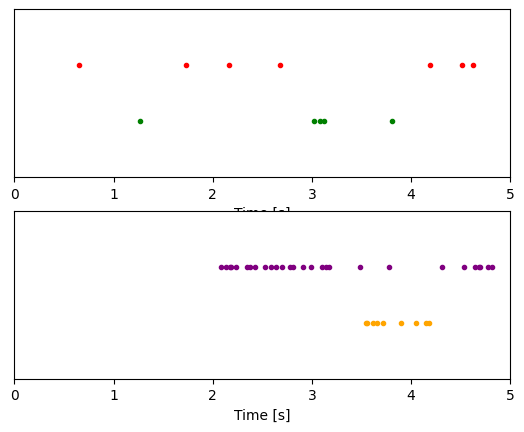

In [30]:
#Makes two subplots with spike train data from trial 1 in the first plot and spike train data 2 in second plot

fig, ax = plt.subplots(2,1)

ax[0].plot(spikes_left_trial1, np.ones_like(spikes_left_trial1), '.', color = 'green')
ax[0].plot(spikes_right_trial1, 2 * np.ones_like(spikes_right_trial1), '.', color = 'red')
ax[0].set_xlim([0, 5])
ax[0].set_ylim([0, 3])
ax[0].set_xlabel('Time [s]')
ax[0].set_yticks([])

ax[1].plot(spikes_left_trial2, np.ones_like(spikes_left_trial2), '.', color = 'orange')
ax[1].plot(spikes_right_trial2, 2 * np.ones_like(spikes_right_trial2), '.', color = 'purple')
ax[1].set_xlim([0, 5])
ax[1].set_ylim([0, 3])
ax[1].set_xlabel('Time [s]')
ax[1].set_yticks([])


This neuron appears to be more bursty during left turn trials, as it fires more consistently after periods of silence.

In [6]:
#Calculates and creates an ISI array for each spike array

ISIsL1 = np.diff(spikes_left_trial1)
ISIsR1 = np.diff(spikes_right_trial1)
ISIsL2 = np.diff(spikes_left_trial2)
ISIsR2 = np.diff(spikes_right_trial2)

Text(0, 0.5, 'Counts')

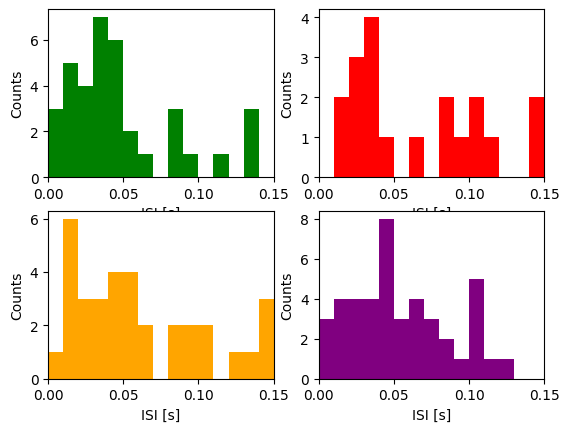

In [24]:
#Makes four histograms for the four ISI arrays with each set to start at time 0, and end at time 2 s, with a bin size equal to 0.01 s

fig, ax = plt.subplots(2,2)

bins = np.arange(0, 2, 1e-2)
ax[0,0].hist(ISIsL1, bins, color = 'green')
ax[0,0].set_xlim([0, 0.15])
ax[0,0].set_xlabel('ISI [s]')
ax[0,0].set_ylabel('Counts')

bins = np.arange(0, 2, 1e-2)
ax[0,1].hist(ISIsR1, bins, color = 'red')
ax[0,1].set_xlim([0, 0.15])
ax[0,1].set_xlabel('ISI [s]')
ax[0,1].set_ylabel('Counts')

bins = np.arange(0, 2, 1e-2)
ax[1,0].hist(ISIsL2, bins, color = 'orange')
ax[1,0].set_xlim([0, 0.15])
ax[1,0].set_xlabel('ISI [s]')
ax[1,0].set_ylabel('Counts')

bins = np.arange(0, 2, 1e-2)
ax[1,1].hist(ISIsR2, bins, color = 'purple')
ax[1,1].set_xlim([0, 0.15])
ax[1,1].set_xlabel('ISI [s]')
ax[1,1].set_ylabel('Counts')

Yes, most of these histograns indicate that the neuron fires in bursts. However, the spikes_right_trial2 appears to have no period of quiescence, which is not reflective of firing in "bursts." This neuron therefore has a higher burstinesss during the left trials, as both of those follow a more consistent pattern of burstiness than the right trials.

In [21]:
#Calculates firing rate across time for each of the four arrays

binsize = 1
L1_bins = np.arange(0,30,binsize)
L_1 = np.zeros(len(L1_bins)-1)
for i in range(len(L1_bins)-1):
  L1spk_index = (spikes_left_trial1 > L1_bins[i]) & (spikes_left_trial1 < L1_bins[i+1])
  true_values = spikes_left_trial1[L1spk_index]
  L_1[i] = (len(true_values))/binsize

binsize = 1
R1_bins = np.arange(0,30,binsize)
R_1 = np.zeros(len(R1_bins)-1)
for i in range(len(R1_bins)-1):
  R1spk_index = (spikes_right_trial1 > R1_bins[i]) & (spikes_right_trial1 < R1_bins[i+1])
  true_values2 = spikes_right_trial1[R1spk_index]
  R_1[i] = (len(true_values2))/binsize

binsize = 1
L2_bins = np.arange(0,30,binsize)
L_2 = np.zeros(len(L2_bins)-1)
for i in range(len(L2_bins)-1):
  L2spk_index = (spikes_left_trial2 > L2_bins[i]) & (spikes_left_trial2< L2_bins[i+1])
  true_values3 = spikes_left_trial2[L2spk_index]
  L_2[i] = (len(true_values3))/binsize

binsize = 1
R2_bins = np.arange(0,30,binsize)
R_2 = np.zeros(len(R2_bins)-1)
for i in range(len(R2_bins)-1):
  R2spk_index = (spikes_right_trial2 > R2_bins[i]) & (spikes_right_trial2 < R2_bins[i+1])
  true_values4 = spikes_right_trial2[R2spk_index]
  R_2[i] = (len(true_values4))/binsize

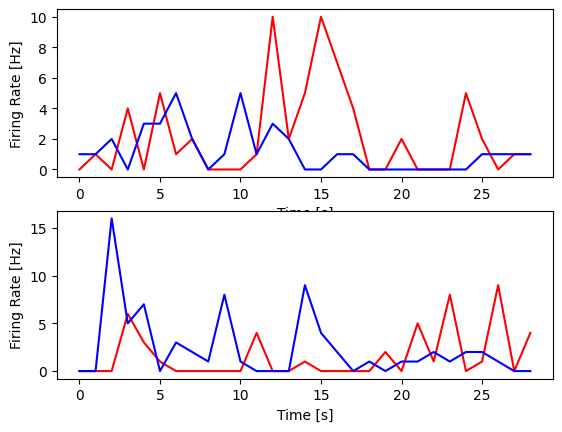

In [22]:
#Creates two subplots and plots the firing rate over time for each trial in the two subplots

fig, ax = plt.subplots(2,1)

ax[0].plot(L1_bins[:-1], L_1, color = 'red')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Firing Rate [Hz]')

ax[0].plot(R1_bins[:-1], R_1, color = 'blue')

ax[1].plot(L2_bins[:-1], L_2, color = 'red')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Firing Rate [Hz]')

ax[1].plot(R2_bins[:-1], R_2, color = 'blue')

Yes, the firing rate between the left and the right trials differ at specific time points.

During trial 1, the left trial had a high increase in firing around 11-18 seconds. This differs from the first right trial, which appears more consistent at that time.

 During trial 2 for the right trial, the highest firing rate occurs from 1-4 seconds. This differs from the second left trial, which has an increase in firing rate after 20 seconds.

 When comparing trials 1 and 2 of the left trial, trial 1 appears to have a higher firing rate earlier on during the 30 second waiting period. Trial 2 has a higher firing rate later on during the waiting period.

 When comparing trials 1 to 2 of the right trial, trial 2 has a higher firing rate than trial 1, but it occurs around a similar span of time.